# Exploratory Data Analysis & Analytical Workflows
**Project Background:** Birhan Energies Market Intelligence Pipeline  
This notebook analyzes structural trend dynamics, stationarity properties, and volatility clustering signatures inside historical Brent crude oil daily spot prices (1987-2022).

## End-to-End Data Analysis Workflow Plan

To ensure analytical rigor for Birhan Energies, this project implements a structured, 5-stage workflow pipeline:
1. **Data Ingestion & Cleaning:** Load historical daily Brent spot prices, format mixed text representations of calendar dates (`format='mixed'`), sort chronologically, and resolve holiday gaps using multi-directional forward/backward imputation (`ffill().bfill()`).
2. **Exploratory Data Analysis (EDA):** Quantify macro cycles via 365-day rolling averages, run Augmented Dickey-Fuller (ADF) unit-root checks, and transform prices into log returns.
3. **Bayesian Change Point Modeling:** Implement a stochastic change point model via `PyMC` using a discrete uniform prior over the index timeline ($\tau$) and exponential distributions to capture shifting volatility regimes.
4. **MCMC Diagnostics & Event Alignment:** Run the sampling chains via `pm.sample()`, verify chain convergence ($\hat{R} \approx 1.0$), and map discovered switch points against a historical database of geopolitical shocks.
5. **Dashboard Synthesis:** Serve pre-computed model parameters over a lightweight Flask REST API to an interactive, responsive frontend application built in React.

In [2]:
import os
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Append workspace root context to look up local source directory packages
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '..')))
from src.data_processing import load_and_clean_data, calculate_log_returns

# Load, sanitize, and verify the time series components
data_path = "../data/raw/BrentOilPrices.csv"
df_raw = load_and_clean_data(data_path)
df_returns = calculate_log_returns(df_raw)

2026-07-13 10:30:17,848 - INFO - Attempting to load dataset from: ../data/raw/BrentOilPrices.csv
2026-07-13 10:30:18,381 - INFO - Data ingestion and processing completed successfully.


## Interpretation of Exploratory Diagnostics

### 1. Trend Analysis
The raw price series plot reveals distinct, multi-year macroeconomic cycles (e.g., the commodities super-cycle expansion up to 2008, followed by sharp market crashes in late 2014 and early 2020). The long-term mean drifts continuously, indicating that the series does not naturally revert to a fixed baseline anchor.

### 2. Stationarity Analysis
* **Raw Prices:** The Augmented Dickey-Fuller (ADF) test yields an ADF statistic of -1.9939 and a p-value of 0.2893. Since the p-value sits far above the standard 0.05 significance threshold, we fail to reject the null hypothesis ($H_0$). The raw series is highly **non-stationary**, meaning direct modeling would yield unstable variances and spurious correlations.
* **Log Returns:** The transformed log returns series ($\log(P_t) - \log(P_{t-1})$) yields an ADF statistic of -16.4271 and a p-value of $2.4986 \times 10^{-29}$. We reject the null hypothesis, confirming that log returns are **strictly stationary** and mathematically viable for change point detection.

### 3. Volatility Patterns
The log returns visualization exhibits a classic financial market property: **volatility clustering**. Extended periods of low, stable market movements are suddenly interrupted by intense, highly dense vertical bars representing high variance. These clusters are heavily grouped around global macro shocks, proving that variance is not constant over time.

In [3]:
# Execute formal stationarity testing checks
def run_adf_diagnostic(series, label):
    res = adfuller(series)
    print(f"[{label} ADF Analysis Results]")
    print(f"ADF Metric Score: {res[0]:.4f} | p-value: {res[1]:.4e}")
    print("Critical Valuation Points:")
    for key, val in res[4].items():
        print(f"   {key}: {val:.4f}")
    print("-" * 40)

run_adf_diagnostic(df_raw['Price'], "Raw Spot Prices")
run_adf_diagnostic(df_returns['Log_Return'], "Continuous Log Returns")

[Raw Spot Prices ADF Analysis Results]
ADF Metric Score: -1.9939 | p-value: 2.8927e-01
Critical Valuation Points:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669
----------------------------------------
[Continuous Log Returns ADF Analysis Results]
ADF Metric Score: -16.4271 | p-value: 2.4986e-29
Critical Valuation Points:
   1%: -3.4311
   5%: -2.8619
   10%: -2.5669
----------------------------------------


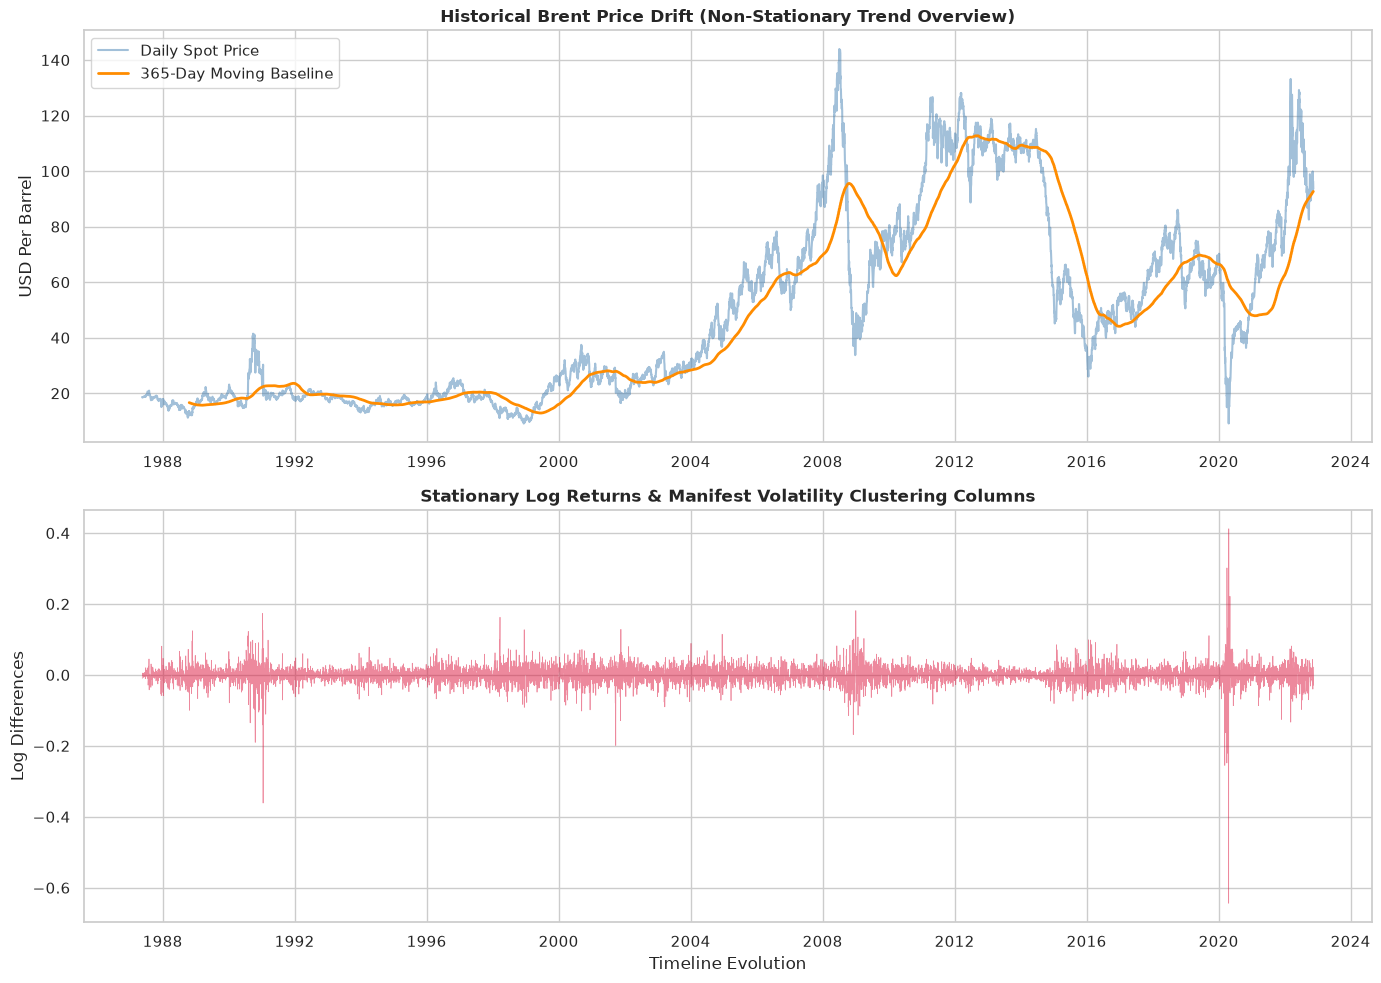

In [4]:
# Generate structural analytical tracking figures
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Visualizing broad historical trend drift
df_raw['Yearly_Moving_Avg'] = df_raw['Price'].rolling(window=365).mean()
axes[0].plot(df_raw['Date'], df_raw['Price'], label='Daily Spot Price', color='steelblue', alpha=0.5)
axes[0].plot(df_raw['Date'], df_raw['Yearly_Moving_Avg'], label='365-Day Moving Baseline', color='darkorange', linewidth=2)
axes[0].set_title("Historical Brent Price Drift (Non-Stationary Trend Overview)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("USD Per Barrel")
axes[0].legend()

# Visualizing active volatility variance clusters
axes[1].plot(df_returns['Date'], df_returns['Log_Return'], color='crimson', alpha=0.5, linewidth=0.5)
axes[1].set_title("Stationary Log Returns & Manifest Volatility Clustering Columns", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Log Differences")
axes[1].set_xlabel("Timeline Evolution")

plt.tight_layout()
plt.show()